In [1]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np 
import random
import torchvision 
import torch.nn.functional as functional

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [2]:
!nvidia-smi

Sun Dec 14 09:14:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 34%   28C    P8            N/A  /  115W |    5136MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Setting uniform seed

In [4]:
torch.manual_seed(32)
torch.cuda.manual_seed(32)
random.seed(42)

In [5]:
# Set Hyper Parameters

In [6]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
LION_LEARNING_RATE= 1e-4
PATCH_SIZE = 4
NUM_CLASSES=10 # for CIFAR
IMAGE_SIZE = 32
CHANNELS = 3
EMBEDDING_DIM = 384
NUM_HEADS = 8
DEPTH = 12 # Number of Transformer Encoder Blocks
MLP_DIM = 512
DROPOUT_RATE=0.1

In [7]:
#Patch Embedding , Create patches and return Tensor of Dimansion :  128 X 65 X 384 : 128 images 65 tokens(patches + CLS) per image, 
#384d per token (384d vector per patch)

class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embedding_dim):
        super().__init__()
        self.patch_size = patch_size
       # IMPORTANT : Use Convolution 2d as Projection Layer as its more efficient than a Linear Layer . The paper actually Mentions a Linear Layer . 
       # kernel and stride are assigned to patch size as we want patches and not overlaps  
        self.projection = nn.Conv2d(in_channels = in_channels, out_channels = embedding_dim, kernel_size = patch_size , stride=patch_size)
       # For square images number of patches is (image size/patch size) ^2         
        num_patches = (image_size//patch_size)**2
        #The CLS token (classification token) in Vision Transformers is a special learnable parameter that serves as a placeholder
        #for aggregating global information from all image patches for classification tasks
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dim))
      #  self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim)) # Random to begin with

                                      
    def forward(self, tensor: torch.Tensor):
            # Tensor is 128 X 3 X 32 X 32 ( 3 , 32, 32 is the image 32X32 with 3 channels) 
            batch_size = tensor.size(0) # Get Batch Size 
            projected_tensor = self.projection(tensor)  # Each patch becomes 384d feature vector Tensor is now : 128*384*8*8
            flattened_tensor = projected_tensor.flatten(2) # flatten 128*384*8*8 to 128, 384, 64
            transposed_tensor = flattened_tensor.transpose(1,2) # swap to : 128 *64*384 converts tensor to format (batch_size, sequence_length, embedding_dim) by swapping dims: 
          #  cls_token = self.cls_token.expand(batch_size, -1, -1) # cls_token is replicated to all 128 images in the batch 
          #  tensor_with_cls_token = torch.cat((cls_token, transposed_tensor), dim=1)   # CLS Token in position 0 , Position 1 to 64 image patches
           # print(transposed_tensor.shape)
            #tensor_with_Pos_Embed = transposed_tensor + self.pos_embed 
         #   print(tensor_with_Pos_Embed.shape)
            return transposed_tensor # 128 X 65 X 384 : 128 images 65 tokens per image ( CLS token + 64 Patches), 384D representation of each token   
    

In [8]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(in_features=in_features, out_features=hidden_features)
        self.fc2 = nn.Linear(in_features=hidden_features, out_features=in_features)
        self.dropout = nn.Dropout(dropout_rate)
    def forward(self, tensor): # EXPAND ACTIVATE PROJECT BACK , Maintains original Dimensions 
        tensor = self.fc1(tensor)  # Tensor is  128 X 65 X 384 , output is 128 X 65 X 512
        tensor = self.dropout(functional.gelu(tensor)) # Input & output is 128 X 65 X 512 , Activation Function : Gaussian Error Linear Unit
        tensor = self.dropout(self.fc2(tensor)) # input is 128 X 65 X 512 and output is 128 X 65 X 384
        return tensor
        

In [9]:
class ConvTransformerEncoder(nn.Module): 
    def __init__(self, embedding_dim, num_heads, mlp_dim, dropout_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embedding_dim) # Mean 0 STD 1 
        # Strides for Convolution as per CVT Paper
        self.q_stride = 1
        self.k_stride = 1
        self.v_stride = 1
        self.kernel_size = 3
        self.in_channels = self.out_channels = embedding_dim
        self.groups = embedding_dim

        # Convolutions for Q K and V . groups is the MOST important thing , as groups  = embedding dimension , 
        # convolution runs on each channel with a 3X3 Kernel, capturing information about neighbors . 
        # Thats why we dont need Positional Embedding , and this is called Local Inductive Bias . 
        
        self.conv_q = nn.Conv2d(in_channels=self.in_channels, 
                                out_channels=self.out_channels, 
                                kernel_size=self.kernel_size,
                                padding = 1,
                                stride = self.q_stride,
                                groups = self.groups
                                )

        self.conv_k = nn.Conv2d(in_channels=self.in_channels, 
                                out_channels=self.out_channels, 
                                kernel_size=self.kernel_size,
                                padding = 1,
                                stride = self.k_stride,
                                groups = self.groups
                                )

        self.conv_v = nn.Conv2d(in_channels=self.in_channels, 
                                out_channels=self.out_channels, 
                                kernel_size=self.kernel_size,
                                padding = 1,
                                stride = self.v_stride,
                                groups = self.groups
                                )
        
        # Each head will process embed_dim/num_heads dimensions so embed_dim%num_heads should be 0 . 
        #batch_first=True: Input shape is (batch, seq, features) → (128, 65, 384)
        # Each head processes: 384 / 12 = 32 dimensions for 12 heads
        # Internally reshaped to: (128, 65, 12, 32) (batch seq heads head_dim) ; Output Concatenated Back to 128 X 65 X 384
        # Pre Norm Architecture ( Norm before addign to Multi Head Attenstion as per VIT Paper)  stabilizes gradients during training, enables training of deeper networks
        #often converges faster than the original "post-norm" design from Attention paper
        self.multiHeadAttn = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, dropout=dropout_rate, batch_first=True)
        # normalizing before each major operation prevents gradient Explosion and Vanishing Gradients during Back Prop
        self.norm2 = nn.LayerNorm(embedding_dim) # Mean 0 STD 1 
        #  position-wise feed-forward network MLP : Applier Non Linear Transformation on the token generated from MHA 
        # MLP applies the same transformation independently to each of the 65 tokens ( 64 Patches + CLS Token ) 
        self.mlp = MLP(embedding_dim, mlp_dim, dropout_rate)

    def forward(self, tensor : torch.Tensor ):
        # Input shape : [128, 65, 384]
      # Remove CLS Token from pensor and perform convolutions on patches only 
        #cls_token = tensor[:, 0:1, :]  # [128, 1, 384]  REMOVE THE CLASS TOKEN 
      #  patches = tensor[:, 1:, :]     # [128, 64, 384]
        patches = tensor
        batch_size, num_patches, embed_dim = patches.shape # 128, 64, 384
        #print("Input Tensor Shape ", tensor.shape)
        #print("batch Size ", batch_size)
        #print("num patches", num_patches)
        #print("Embedding Dim ", embed_dim)
        height = width = np.sqrt(num_patches).astype(np.int64) 
        # Normalize - Layer Norm
        patches = self.norm1(patches)
        #print("Normalized Tensor Shape ", patches.shape)
        patches_transposed = patches.transpose(1,2) #128 64 384 -> 128 384 64
        # Convert to Spacial Format for Convolution
        #print("Transposed Tensor Shape", patches_transposed.shape)
        patches_spacial = patches_transposed.reshape(batch_size, embed_dim, height, width) # [128, 384, 8, 8] 
        
        q = self.conv_q(patches_spacial) # [128, 384, 8, 8]
        k = self.conv_k(patches_spacial) # [128, 384, 8, 8]
        v = self.conv_v(patches_spacial) # [128, 384, 8, 8]
        # back to sequence format for attention - > Flatten and Transpose 
        q = q.flatten(2).transpose(1, 2) # 128, 64, 384
        k = k.flatten(2).transpose(1, 2) # 128, 64, 384
        v = v.flatten(2).transpose(1, 2) # 128, 64, 384 
        #q_with_cls = torch.cat([cls_token, q], dim=1) # [128, 65, 384]
        #k_with_cls = torch.cat([cls_token, k], dim=1) # [128, 65, 384]
        #v_with_cls = torch.cat([cls_token, v], dim=1) # [128, 65, 384]
        #print("q after adding cls token", q_with_cls.shape)
        # q k v for Mutlihead Self Attention come from convolutions unlike VIT
        attn_output, attn_weights = self.multiHeadAttn(query = q , key= k , value = v) 
        tensor = tensor + attn_output # Residual Conenction : Add Original Input to the output from Multi Head Attention 
        tensor = tensor + self.mlp(self.norm2(tensor)) 
        return tensor # Shape 128 X 65 X 384 maintained

In [10]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, num_classes, embedding_dim, depth, num_heads, mlp_dims, dropout_rate):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embedding_dim)
        self.encoder = nn.Sequential(
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate)
            
        )
        self.norm = nn.LayerNorm(embedding_dim)
        # logits=W⋅x+b , Output is logits of num classes size vector
        self.classification_head = nn.Linear(in_features = embedding_dim, out_features= 100) # Linear Classification Head 

    def forward(self, tensor):
        tensor_with_Pos_Embed = self.patch_embed(tensor)
        encoder_output = self.encoder(tensor_with_Pos_Embed)
        normed_encoder_output = self.norm(encoder_output)
        # Global Average Pooling (GAP)
        G_A_P_OP = normed_encoder_output.mean(dim=1) # 
        return self.classification_head(G_A_P_OP) # Output Shape is 128 X 100  ( 100 Classes) 

In [11]:
# Init the Vision transformer Model

model = VisionTransformer(IMAGE_SIZE, PATCH_SIZE,CHANNELS,NUM_CLASSES, EMBEDDING_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROPOUT_RATE ).to(device)

In [12]:
model

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 384, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): ConvTransformerEncoder(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (conv_q): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=384)
      (conv_k): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=384)
      (conv_v): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=384)
      (multiHeadAttn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
      )
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=384, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvTransformerEn

In [13]:
# IMAGE TRANSFORM and dataset prep

In [14]:
cifar100_mean = [0.5071, 0.4865, 0.4409]
cifar100_std = [0.2673,0.2564,0.2762]

train_transformer = transforms.Compose([
transforms.RandomCrop(32, padding=4),    
transforms.RandomHorizontalFlip(),
transforms.RandAugment(num_ops=2, magnitude=9),
transforms.ToTensor(),
transforms.Normalize(cifar100_mean, cifar100_std),
    
])

train_dataset = datasets.CIFAR100(root="cifar100_data", train=True, download = True, transform = train_transformer)

In [15]:
train_dataset

Dataset CIFAR100
    Number of datapoints: 50000
    Root location: cifar100_data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               RandAugment(num_ops=2, magnitude=9, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2762])
           )

In [16]:
# Load Testing Data 

test_transformer = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(cifar100_mean, cifar100_std)
])

test_dataset = datasets.CIFAR100(root="cifar100_data", train=False, download = True, transform = test_transformer)

In [17]:
test_dataset

Dataset CIFAR100
    Number of datapoints: 10000
    Root location: cifar100_data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.5071, 0.4865, 0.4409], std=[0.2673, 0.2564, 0.2762])
           )

In [18]:
#DataLoaders

dataloader_train = DataLoader(train_dataset, batch_size=128, shuffle=True)
dataloader_test = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"TRAIN DATALOADER : {len(dataloader_train)} batches")
print(f"TEST DATALOADER : {len(dataloader_test)} batches")

TRAIN DATALOADER : 391 batches
TEST DATALOADER : 79 batches


In [19]:


# Training

def train(model, loader : DataLoader, optimizer, loss_function):
    model.train()
    correct, total_loss = 0, 0  
    for img_batch, labels in loader:
        img_batch = img_batch.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(img_batch)
        loss = loss_function(output, labels)
        loss.backward() # Back Prop 
        optimizer.step() # gradient Descent
        total_loss+= loss.item() * img_batch.size(0)
        correct+= (output.argmax(1)==labels).sum().item()
    return total_loss/len(loader.dataset) , correct/len(loader.dataset)  

In [20]:
# Evaluation
def evaluate_model(model, loader : DataLoader):
    model.eval()
    correct = 0
    with torch.inference_mode():
        for img_batch, labels in loader:
            img_batch = img_batch.to(device)
            labels = labels.to(device)
            output = model(img_batch)
            predictions = output.argmax(dim=1)
            correct+= (predictions==labels).sum().item()
        return correct/len(loader.dataset)      

In [21]:
#from tqdm.auto import tqdm

In [22]:
from lion_pytorch import Lion

train_accuracies, test_accuracies = [], []
EPOCHS=100
# Cross Entropy Loss and AdamW Optimizer 
loss_function = nn.CrossEntropyLoss()
#optimizer_lion = Lion(model.parameters(), lr=3e-5, weight_decay=0.1)


optimizer = optim.AdamW(params=model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=0.01) 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
 
for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, dataloader_train, optimizer, loss_function)
    test_acc = evaluate_model(model, dataloader_test)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch : {epoch+1} of {EPOCHS}, Train Loss : {train_loss:.4f} , Train Accuracy : {train_acc:.4f}, Test Accuracy : {test_acc:.4f}")
    scheduler.step() 

Epoch : 1 of 100, Train Loss : 4.0650 , Train Accuracy : 0.0786, Test Accuracy : 0.1630
Epoch : 2 of 100, Train Loss : 3.4513 , Train Accuracy : 0.1726, Test Accuracy : 0.2609
Epoch : 3 of 100, Train Loss : 3.0585 , Train Accuracy : 0.2455, Test Accuracy : 0.3146
Epoch : 4 of 100, Train Loss : 2.7596 , Train Accuracy : 0.3022, Test Accuracy : 0.3802
Epoch : 5 of 100, Train Loss : 2.5352 , Train Accuracy : 0.3486, Test Accuracy : 0.4161
Epoch : 6 of 100, Train Loss : 2.3420 , Train Accuracy : 0.3934, Test Accuracy : 0.4553
Epoch : 7 of 100, Train Loss : 2.1869 , Train Accuracy : 0.4264, Test Accuracy : 0.4779
Epoch : 8 of 100, Train Loss : 2.0594 , Train Accuracy : 0.4531, Test Accuracy : 0.4898
Epoch : 9 of 100, Train Loss : 1.9328 , Train Accuracy : 0.4796, Test Accuracy : 0.5313
Epoch : 10 of 100, Train Loss : 1.8286 , Train Accuracy : 0.5047, Test Accuracy : 0.5440
Epoch : 11 of 100, Train Loss : 1.7352 , Train Accuracy : 0.5274, Test Accuracy : 0.5526
Epoch : 12 of 100, Train Loss 

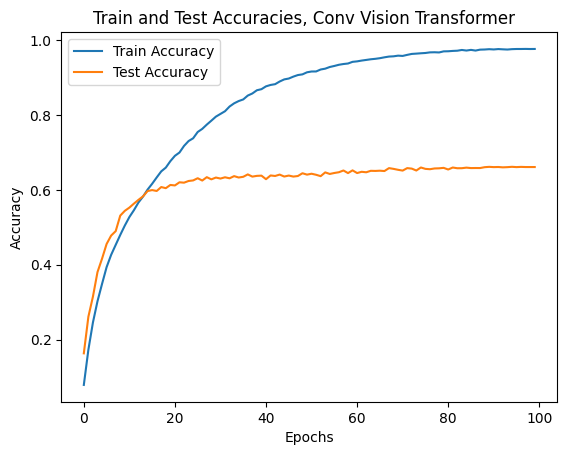

In [23]:
plt.plot(train_accuracies, label = "Train Accuracy")
plt.plot(test_accuracies, label = "Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train and Test Accuracies, Conv Vision Transformer  ")
plt.savefig("ConvVisionTransformer-NoCLSToken-GAP-CIFAR100",  dpi=300)
plt.show()

In [24]:
torch.save(model, 'ConvVisionTransformer-NoCLSToken-GAP-CIFAR100.pth')

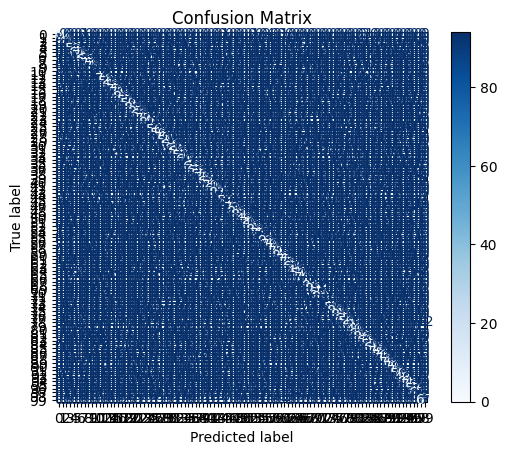

Precision: 0.66
Recall:    0.66
F1 Score:  0.66


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('ConvVisionTransformer-NoCLSToken-GAP-CIFAR100.pth', weights_only=False)

def test_model(model, loader : DataLoader):
    model.eval()
    correct = 0
    all_labels = []
    all_predictions = []
    with torch.inference_mode():
        for img_batch, labels in loader:
            img_batch = img_batch.to(device)
            labels = labels.to(device)
            output = model(img_batch)
            predictions = output.argmax(dim=1)
            correct+= (predictions==labels).sum().item()
            all_labels.extend(labels.to("cpu").numpy())
            all_predictions.extend(predictions.to("cpu").numpy())
        return correct/len(loader.dataset), all_labels, all_predictions   

test_accuracy, all_labels, all_predictions = test_model(model, dataloader_test)
        
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig("ConvVisionTransformer-NoCLSToken-GAP-CIFAR100ConfusionMatrix.png",  dpi=300)
plt.show()

precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.448713..1.4146622].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43341827..1.3254757].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.41812354..1.512129].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42577088..1.512129].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25555867..1.3926556].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22693938..1.5050297].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4338

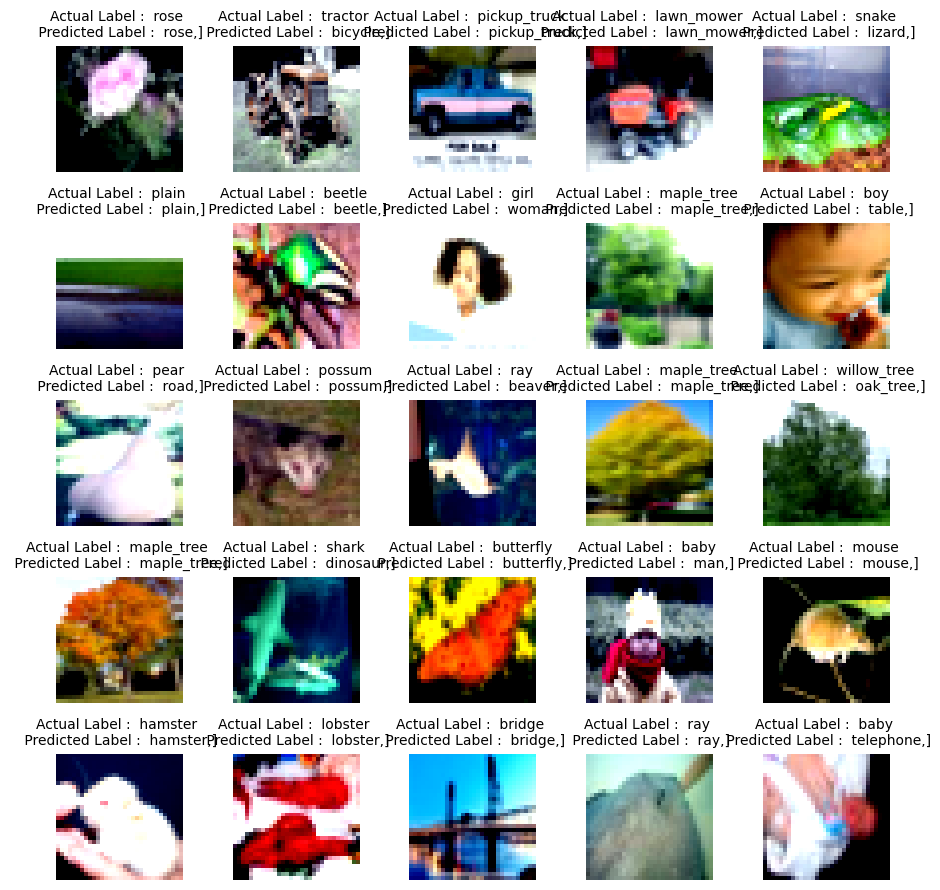

In [26]:
grid_size = 5
fig, axes = plt.subplots(grid_size, grid_size, figsize = (9, 9))
classes = test_dataset.classes
model = torch.load('ConvVisionTransformer-NoCLSToken-GAP-CIFAR100.pth', weights_only=False)

model.eval()

for i in range(grid_size):
    for j in range(grid_size):
        index = random.randint(0, len(test_dataset) -1)
        img , correct_label = test_dataset[index]
        input_tensor = img.unsqueeze(dim=0).to(device)
        with torch.inference_mode():
            output = model(input_tensor)
            _, predicted = torch.max(output.data,1)
        img = img / 2 + 0.5 # denormalizing images to plot 
        nump_img = img.to("cpu")
        axes[i, j].imshow(np.transpose(nump_img, (1,2,0)))
        correct_match = classes[correct_label] == classes[predicted.item()]
        axes[i, j].set_title(f"Actual Label :  {classes[correct_label]} \n Predicted Label :  {classes[predicted.item()]},]" , fontsize = 10)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()